In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import cupy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
print("GPU khả dụng:" , torch.cuda.is_available())
if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))

GPU khả dụng: True
Tên GPU: Tesla T4


In [4]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).

# Network parameters.
n_hidden_1 = 128 # 1st layer number of neurons.
n_hidden_2 = 256 # 2nd layer number of neurons.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
x_train, x_test = x_train.reshape([-1, num_features]).T, x_test.reshape([-1, num_features]).T
# Chuẩn hóa ảnh từ from [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.


In [8]:
m = x_train.shape[1]
x_train = np.array(x_train) # Đẩy mảng x_train lên GPU
y_train = np.array(y_train) # Đẩy nhãn y_train lên GPU

In [9]:
def init_params():
    W1 = (np.random.rand(n_hidden_1, 784) - 0.5) * 0.1
    b1 = (np.random.rand(n_hidden_1, 1) - 0.5) * 0.1
    W2 = (np.random.rand(n_hidden_2, n_hidden_1) - 0.5) * 0.1
    b2 = (np.random.rand(n_hidden_2, 1) - 0.5) * 0.1
    W3 = (np.random.rand(num_classes,n_hidden_2) - 0.5) * 0.1
    b3 = (np.random.rand(num_classes,1) - 0.5) *0.1
    return W1, b1, W2, b2, W3, b3

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True)) # Trừ max để tránh lỗi tràn số (overflow)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def cross_entropy(predictions, targets, epsilon=1e-12):
    """
    tính giá trị cross entropy giữa targets và predictions. 
    Input: predictions (N, k)
           targets (N, k)        
    Returns: scalar
    """
    predictions = np.clip(predictions, epsilon, 1. - epsilon)
    N = predictions.shape[0]
    ce = -np.sum(targets*np.log(predictions+1e-9))/N
    return ce
    
def forward_prop(W1, b1, W2, b2,W3, b3, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)
    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2,Z3,A3

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    # Ép kiểu size và max về int để CuPy hiểu được
    rows = int(Y.size)
    cols = int(Y.max() + 1)
    
    # Tạo ma trận zeros trên GPU
    one_hot_Y = np.zeros((rows, cols))
    
    # Gán giá trị 1 trên GPU
    one_hot_Y[np.arange(rows), Y] = 1
    
    return one_hot_Y.T

def backward_prop(Z1, A1, Z2, A2, Z3,A3, W1, W2,W3, X, Y):
    one_hot_Y = one_hot(Y)
    
    dz3 = A3 - one_hot_Y
    dw3 = 1 / m * dz3.dot(A2.T)
    db3 = 1 / m * np.sum(dz3, axis = 1, keepdims=True)
    dz2 = W3.T.dot(dz3) * ReLU_deriv(Z2)
    dW2 = 1 / m * dz2.dot(A1.T)
    db2 = 1 / m * np.sum(dz2, axis = 1, keepdims=True)
    dz1 = W2.T.dot(dz2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dz1.dot(X.T)
    db1 = 1 / m * np.sum(dz1, axis = 1, keepdims=True)
    return dW1, db1, dW2, db2, dw3, db3

def update_params(W1, b1, W2, b2,W3,b3, dW1, db1, dW2, db2,dW3, db3, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    W3 = W3 - alpha * dW3  
    b3 = b3 - alpha * db3    
    return W1, b1, W2, b2, W3, b3

In [10]:
losses = []
def get_predictions(A3):
    return np.argmax(A3, 0)

def get_accuracy(predictions, Y):
    # print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2, W3, b3 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2, Z3,A3 = forward_prop(W1, b1, W2, b2,W3,b3, X)
        dW1, db1, dW2, db2, dW3, db3 = backward_prop(Z1, A1, Z2, A2,Z3,A3, W1, W2,W3, X, Y)
        W1, b1, W2, b2,W3, b3 = update_params(W1, b1, W2, b2,W3,b3, dW1, db1, dW2, db2,dW3, db3, alpha)
        predictions = get_predictions(A3)
        losses.append(cross_entropy(predictions, Y))
        if i % 10 == 9:
            # print("Iteration: ", i+1)
            # predictions = get_predictions(A2)
            # print('Accuracy: %.3f' %(get_accuracy(predictions, Y)))
            print('Iteration: %d, accuracy: %.3f' %(i + 1, get_accuracy(predictions, Y)))
    return W1, b1, W2, b2, W3, b3

In [14]:
alpha = 0.3
W1, b1, W2, b2, W3, b3 = gradient_descent(x_train, y_train, alpha, 500)

Iteration: 10, accuracy: 0.402
Iteration: 20, accuracy: 0.611
Iteration: 30, accuracy: 0.712
Iteration: 40, accuracy: 0.787
Iteration: 50, accuracy: 0.795
Iteration: 60, accuracy: 0.752
Iteration: 70, accuracy: 0.855
Iteration: 80, accuracy: 0.866
Iteration: 90, accuracy: 0.879
Iteration: 100, accuracy: 0.837
Iteration: 110, accuracy: 0.894
Iteration: 120, accuracy: 0.898
Iteration: 130, accuracy: 0.900
Iteration: 140, accuracy: 0.883
Iteration: 150, accuracy: 0.907
Iteration: 160, accuracy: 0.911
Iteration: 170, accuracy: 0.914
Iteration: 180, accuracy: 0.916
Iteration: 190, accuracy: 0.919
Iteration: 200, accuracy: 0.921
Iteration: 210, accuracy: 0.923
Iteration: 220, accuracy: 0.925
Iteration: 230, accuracy: 0.926
Iteration: 240, accuracy: 0.928
Iteration: 250, accuracy: 0.929
Iteration: 260, accuracy: 0.930
Iteration: 270, accuracy: 0.930
Iteration: 280, accuracy: 0.933
Iteration: 290, accuracy: 0.936
Iteration: 300, accuracy: 0.937
Iteration: 310, accuracy: 0.939
Iteration: 320, a

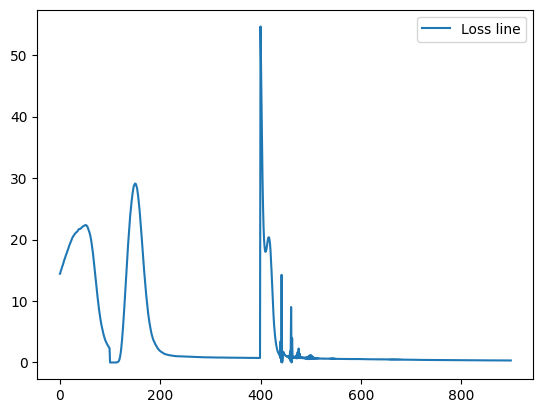

In [21]:
# Cách 1: Dùng list comprehension với .get() để lấy giá trị thực từ GPU về CPU
losses_cpu = [loss.get() if hasattr(loss, 'get') else loss for loss in losses]

# Vẽ biểu đồ với dữ liệu đã ở trên CPU
plt.plot([i for i in range(len(losses_cpu))], losses_cpu, label='Loss line')
plt.legend()
plt.show()